# Example-31: Frequency bootstrap

In [1]:
# In this example input signal is randomly sampled (with replacement)
# NUFFT is used to estimate frequencies for each random sample
# This allows some uncertainty quantification for a signal frequency

# Frequency uncertainty can be also estimated with OLS fit of parabola or using shifted samples

In [2]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [3]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

In [4]:
# Estimate frequency from a signal with noise using parabola estimator
# Here full signal is used to estimate (main) frequency

# Set parameters

length = 1024

# Set signal (harmonic signal with two components)

time = torch.linspace(1, length, length, dtype=dtype, device=device)
signal = 1.0*torch.cos(2.0*numpy.pi*1.0*0.12345*time) + 0.1*torch.cos(2.0*numpy.pi*2.0*0.12345*time)

# Set signal with noise

signal += 0.10*torch.randn_like(signal)

# Set tbt

w = Window.from_cosine(length, 1.0, dtype=dtype, device=device)
d = Data.from_data(w, signal.reshape(1, -1))

# Remove mean and apply window

d.window_remove_mean()
d.window_apply()

# Estimate frequency

f = Frequency(d)
f('parabola')

# Reset tbt
d.reset()

# Print estimation error

print(abs(0.12345 - f.frequency.mean().item()))

8.436572903475215e-07


In [5]:
# Estimate frequency using NUFFT from one random sample

# Set sample size

size = 512

# Set sample

time = torch.randint(length, (1, size), dtype=torch.int64, device=device).squeeze()
data = signal[time]

# Initial frequency estimation

grid = 2.0*numpy.pi*numpy.linspace(0.0, 0.5, len(time))
spectrum = numpy.abs(nufft.nufft1d3(time.cpu().numpy(), data.cpu().numpy(), grid))
index = numpy.argmax(spectrum)
frequency = grid[index]/(2*numpy.pi)

# Refined estimation

omega_min = grid[index - 1]
omega_max = grid[index + 1]
grid = numpy.linspace(omega_min, omega_max, len(grid))
spectrum = numpy.abs(nufft.nufft1d3(time.cpu().numpy(), data.cpu().numpy(), grid))
index = numpy.argmax(spectrum)
frequency = grid[index]/(2*numpy.pi)

# Print estimation error

print(abs(0.12345 - frequency))

1.1057900360378348e-05


In [6]:
# Bootstrap estimator
# Note, sample size can be larger than signal length

result = []
for _ in range(1024):
    
    size = 2048
    
    time = torch.randint(length, (1, size), dtype=torch.int64, device=device).squeeze()
    data = signal[time]

    grid = 2.0*numpy.pi*numpy.linspace(0.0, 0.5, len(time))
    spectrum = numpy.abs(nufft.nufft1d3(time.cpu().numpy(), data.cpu().numpy(), grid))
    index = numpy.argmax(spectrum)
    frequency = grid[index]/(2*numpy.pi)

    omega_min = grid[index - 1]
    omega_max = grid[index + 1]
    grid = numpy.linspace(omega_min, omega_max, len(grid))
    spectrum = numpy.abs(nufft.nufft1d3(time.cpu().numpy(), data.cpu().numpy(), grid))
    index = numpy.argmax(spectrum)
    frequency = grid[index]/(2*numpy.pi)
    
    result.append(frequency)
    
result = torch.tensor(result, dtype=dtype, device=device)

# Bootstrap result
# Note, data can be filtered/cleaned

print(abs(0.12345 - result.mean()))
print(result.std())

tensor(5.564851450479e-08, dtype=torch.float64)
tensor(9.133249308026e-06, dtype=torch.float64)


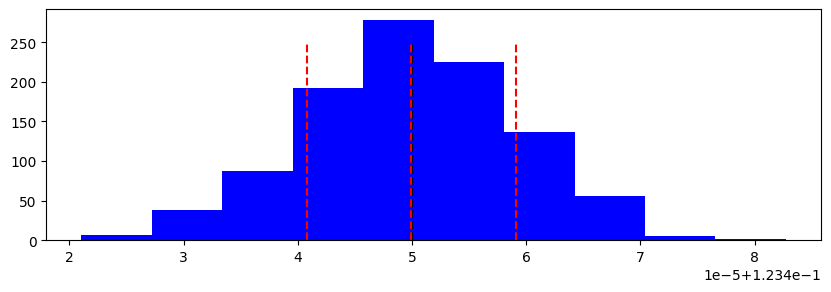

In [7]:
# Plot results

plt.figure(figsize=(10, 3))
plt.hist(result.cpu().numpy(), color='blue')
plt.vlines(0.12345, 0, 250, linestyles='dashed', color='black')
plt.vlines([result.mean() - result.std(), result.mean(), result.mean() + result.std()], 0, 250, linestyles='dashed', color='red')
plt.show()

In [8]:
# Or use compute_bootstrapped_frequency method to estimate frequencies and errors for all signals

f.compute_bootstrapped_frequency(length=1024, count=2048)

tensor([[1.234498934865e-01, 8.701559175202e-06]], dtype=torch.float64)